In [23]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import depletion_analysis
from scipy.optimize import curve_fit
import scienceplots
import PNAS_data
import uncertainties as unc
from uncertainties import unumpy as unp
import os
import utils as uts
from matplotlib.ticker import ScalarFormatter
from lmfit import Model
import string
import re
import sodium_crowder_equilibrium_constant as scec

Fit failed for nan: `ydata` must not be empty!


C:\Users\tpiros\AppData\Local\Temp\ipykernel_14396\2291537576.py:27: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(7, 5.6))
C:\Users\tpiros\Desktop\molecular_crowding-master\.venv2\Lib\site-packages\scipy\optimize\_minpack_py.py:989: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma
C:\Users\tpiros\AppData\Local\Temp\ipykernel_14396\2291537576.py:19: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(quad_model, x, log_y, sigma=yerr/y, absolute_sigma=True)
C:\Users\tpiros\AppData\Local\Temp\ipykernel_14396\2291537576.py:41: RuntimeWarning: overflow encountered in exp
  y_fit = np.exp(lnK_fit)
C:\Users\tpiros\Desktop\molecular_crowd

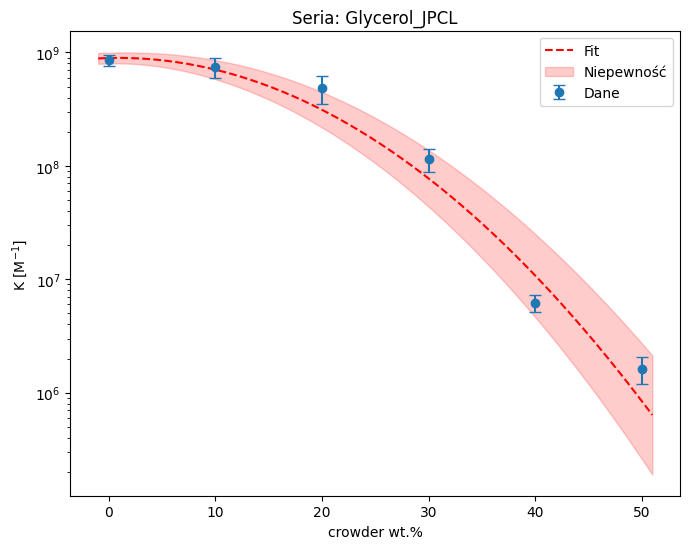

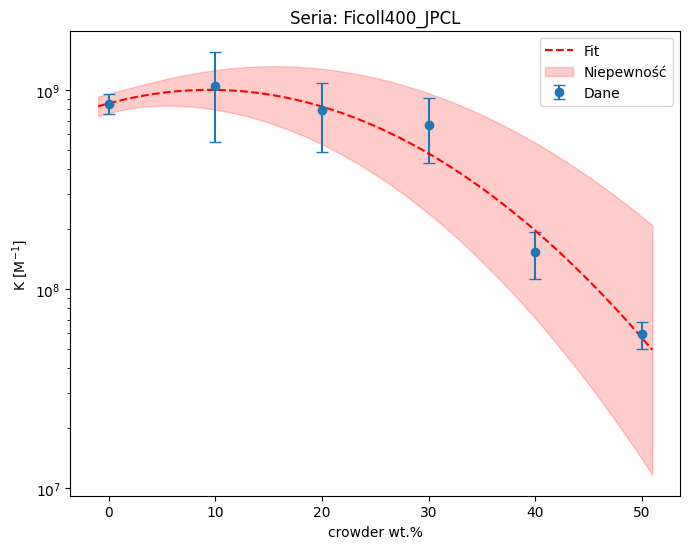

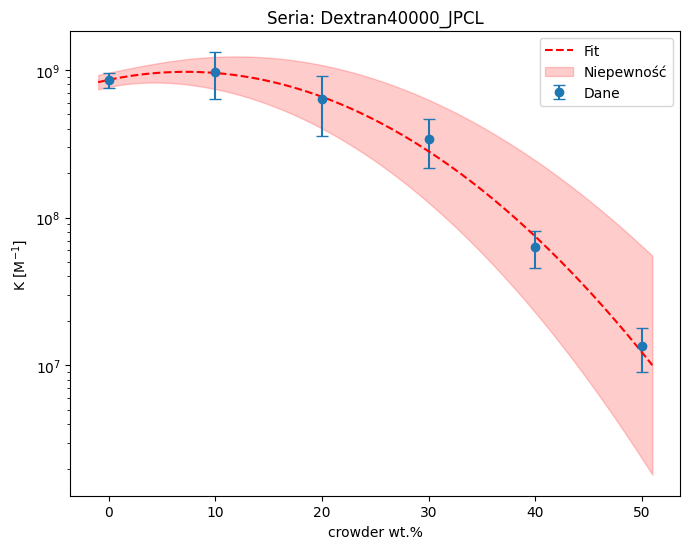

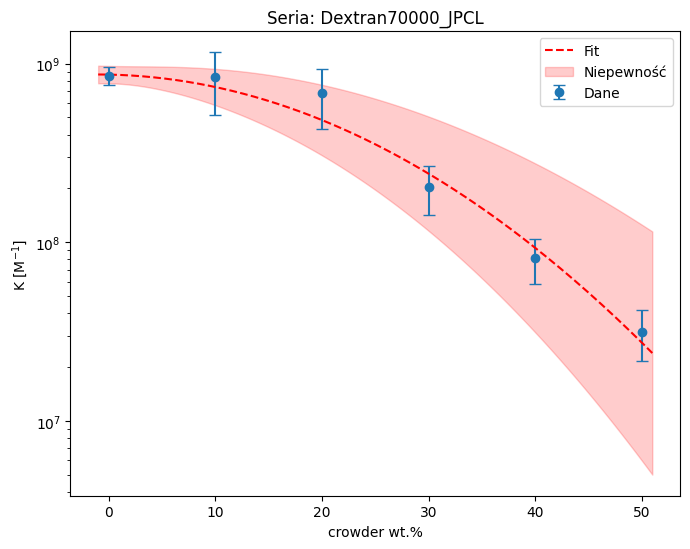

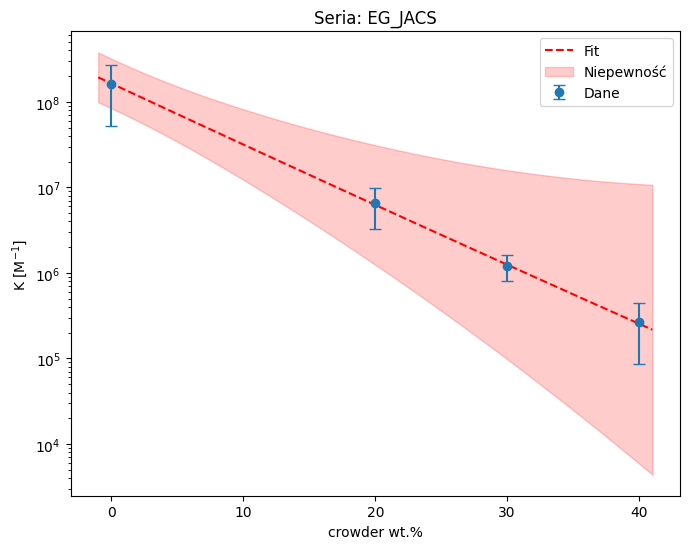

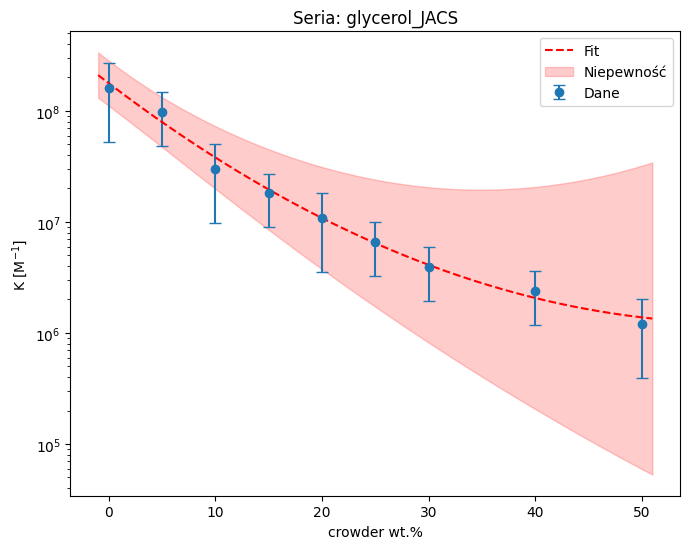

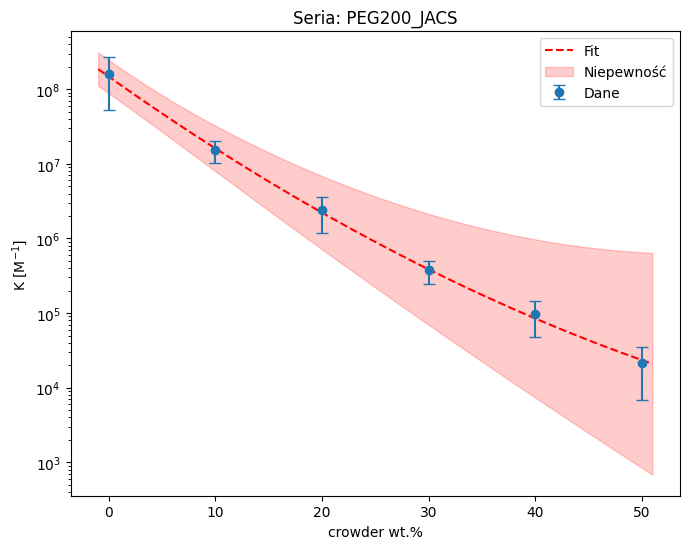

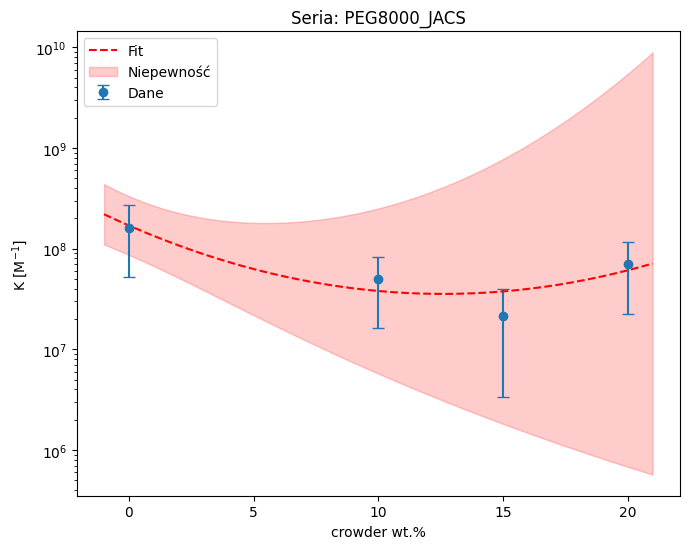

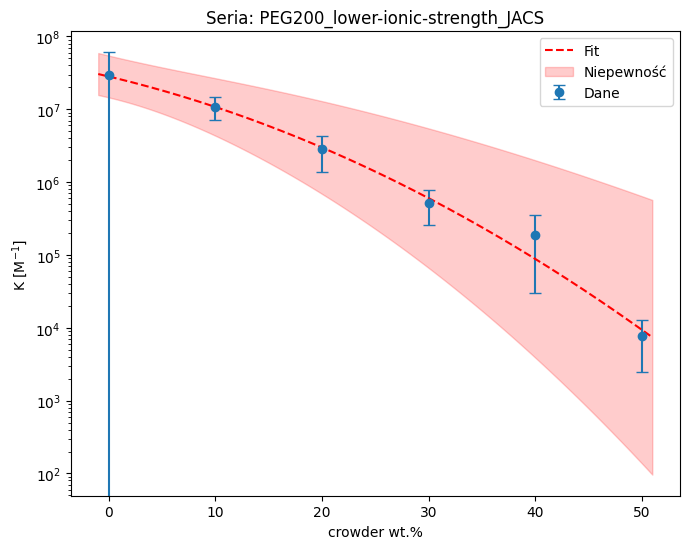

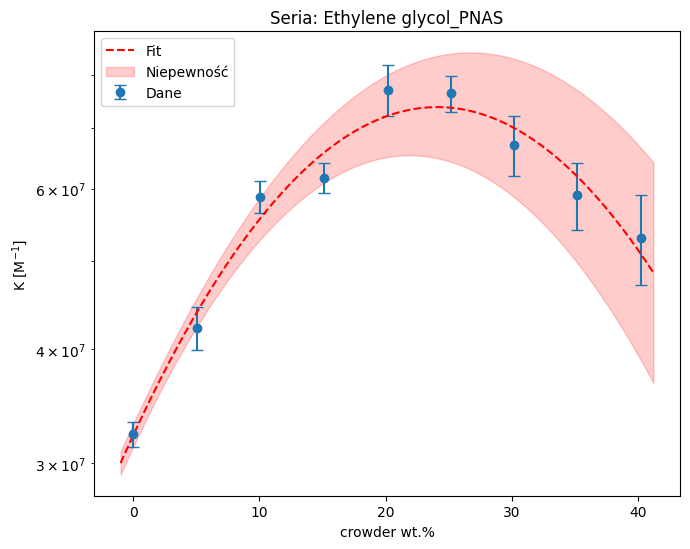

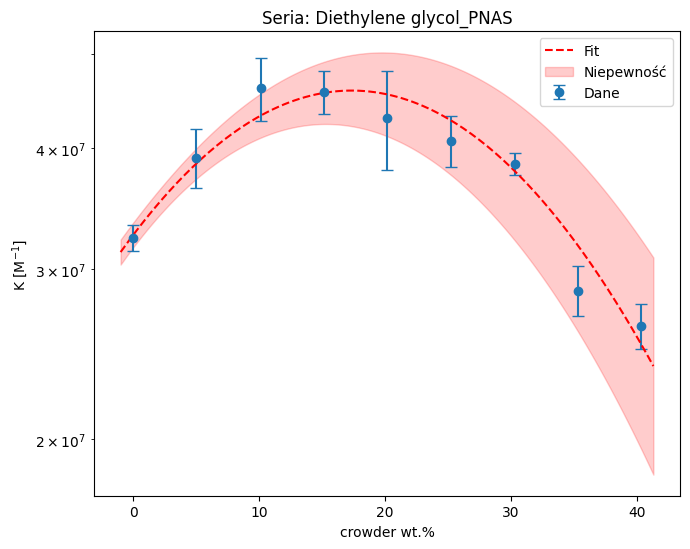

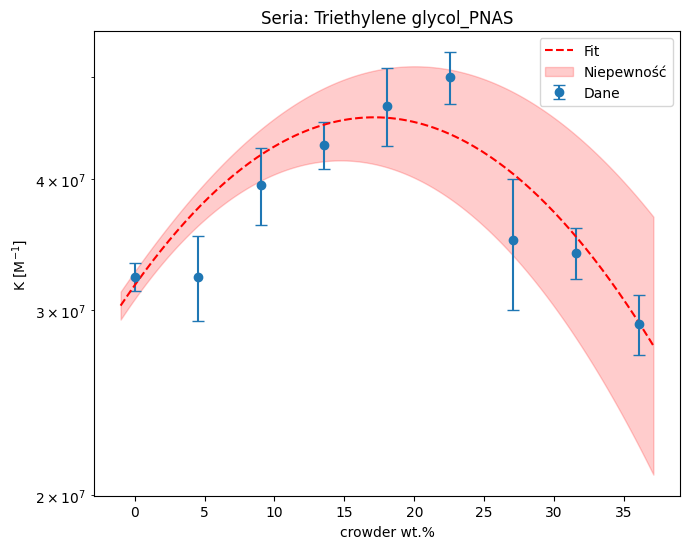

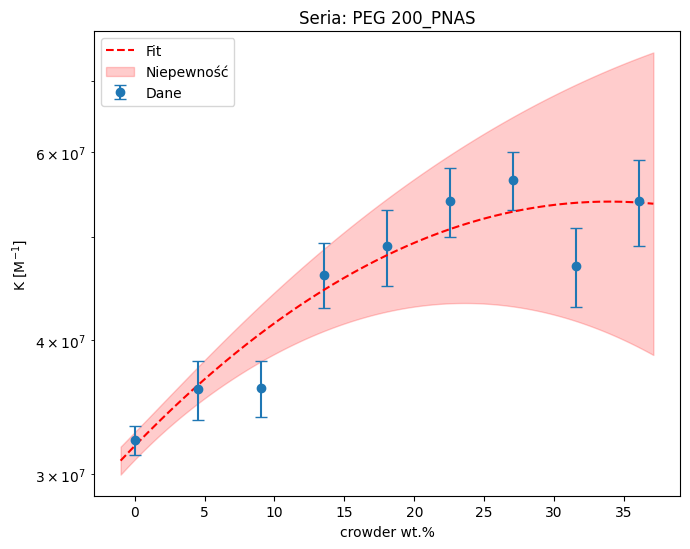

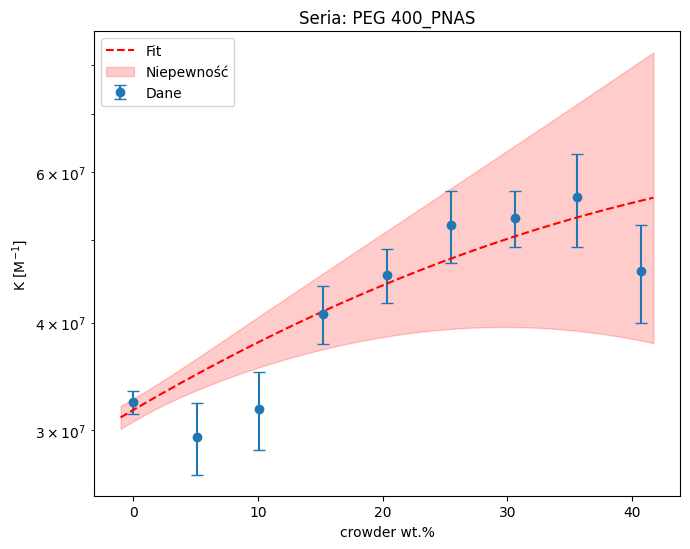

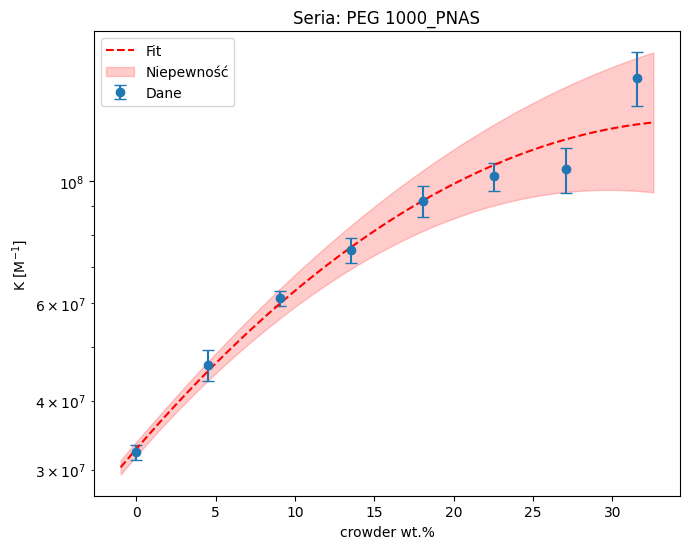

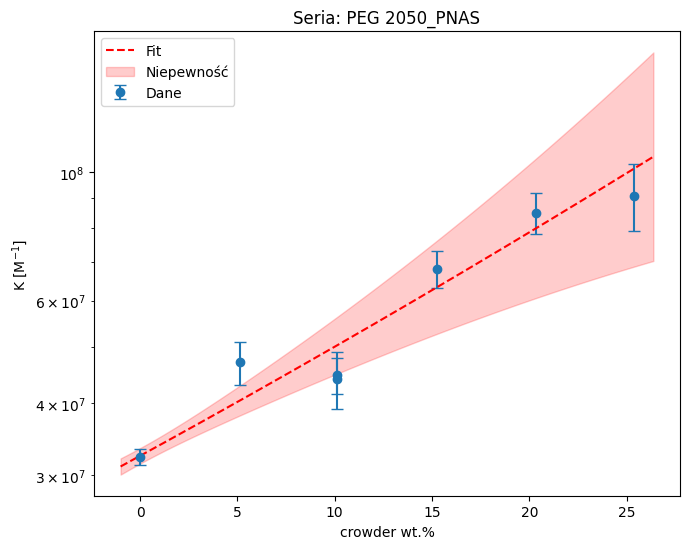

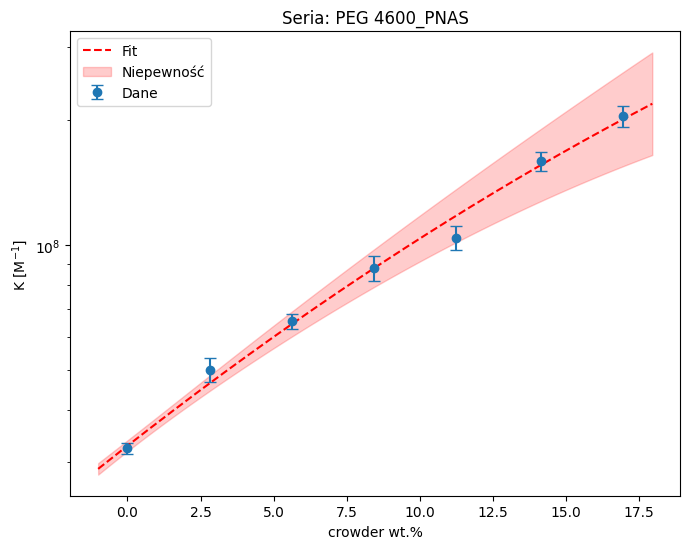

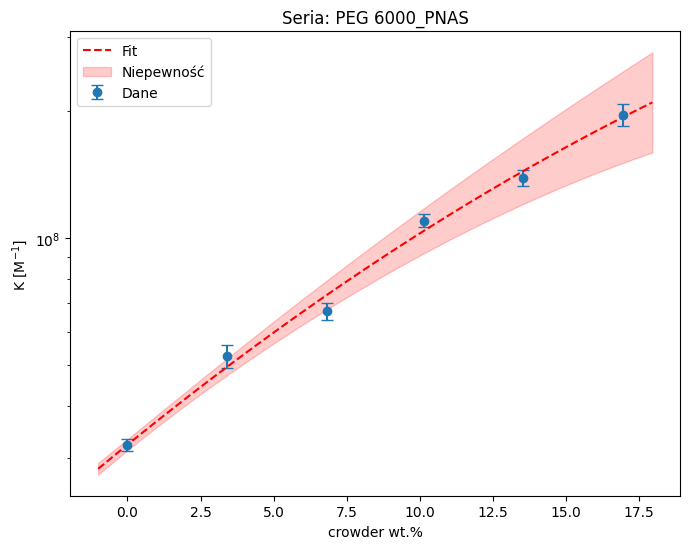

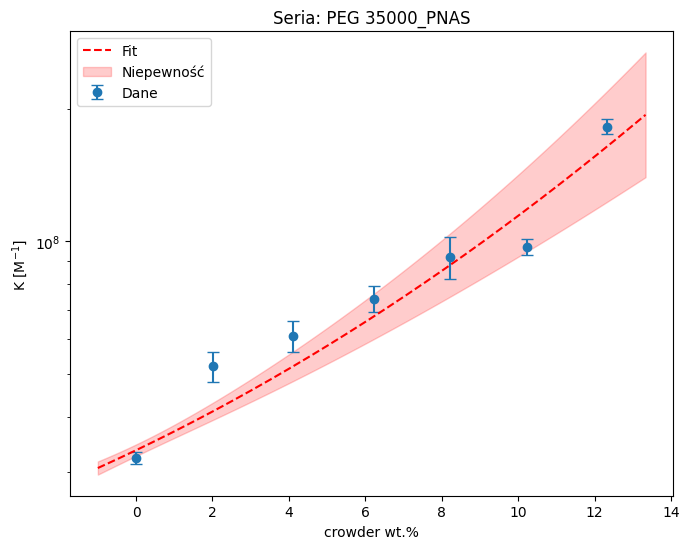

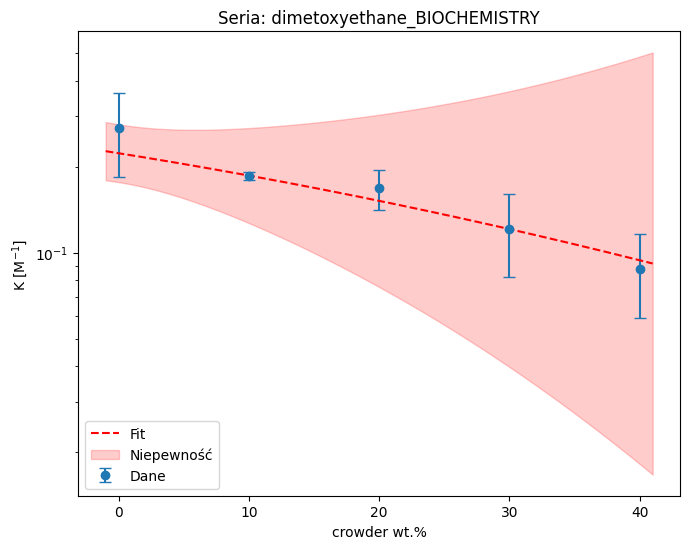

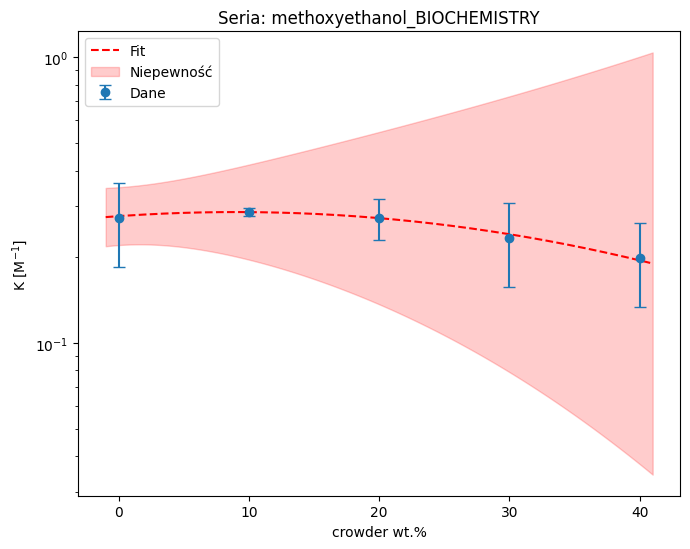

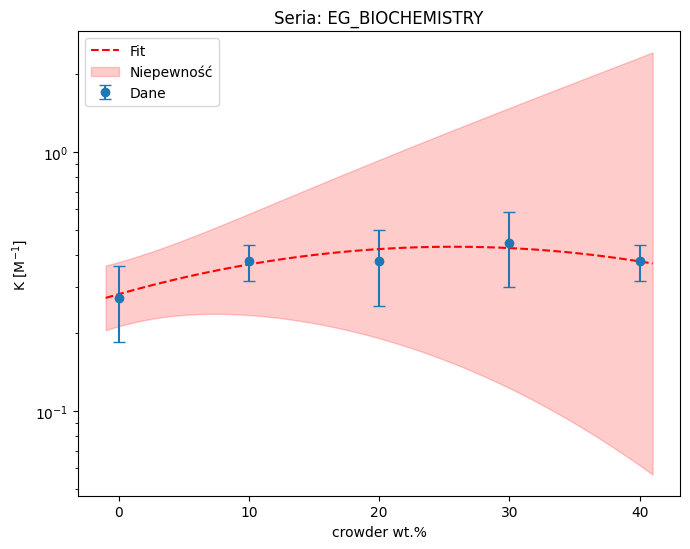

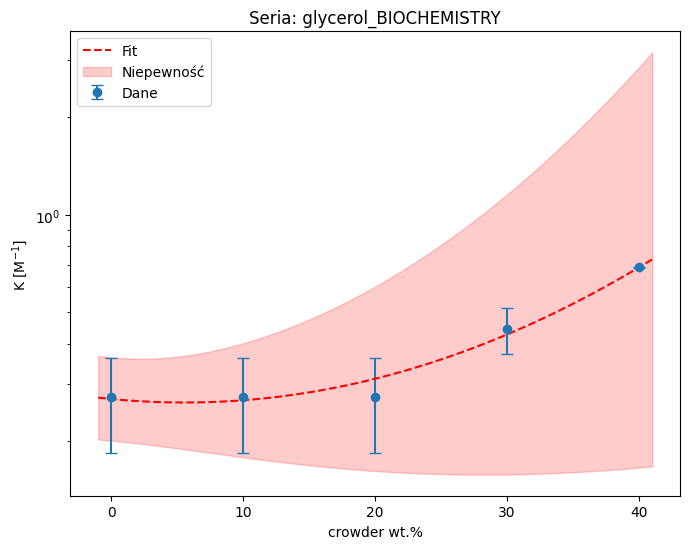

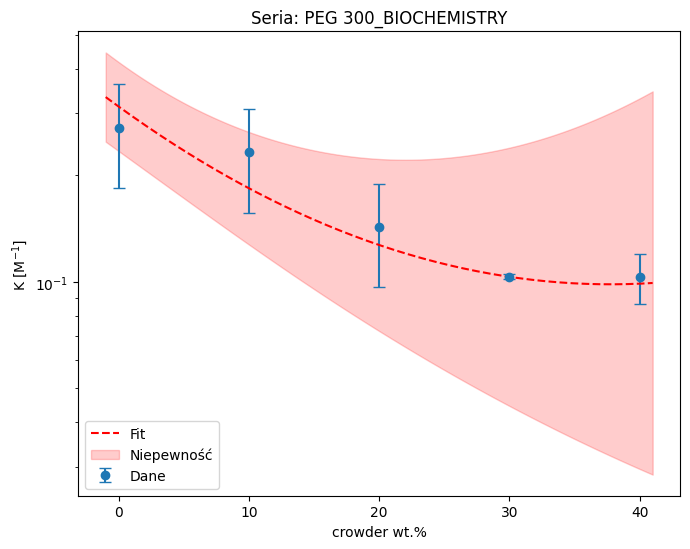

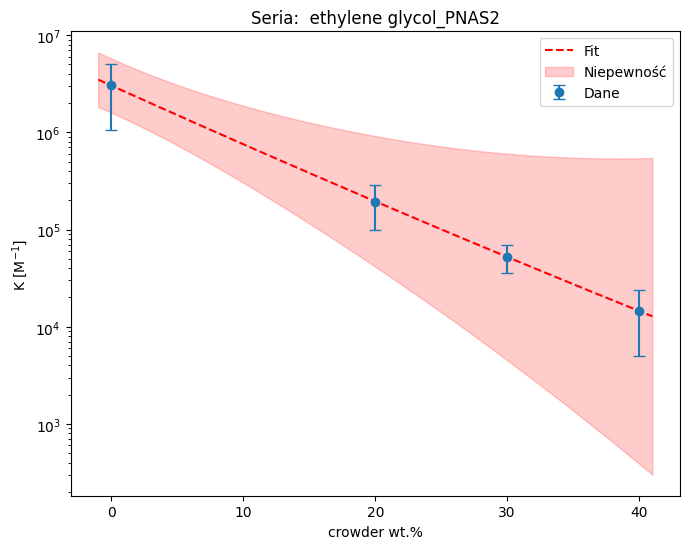

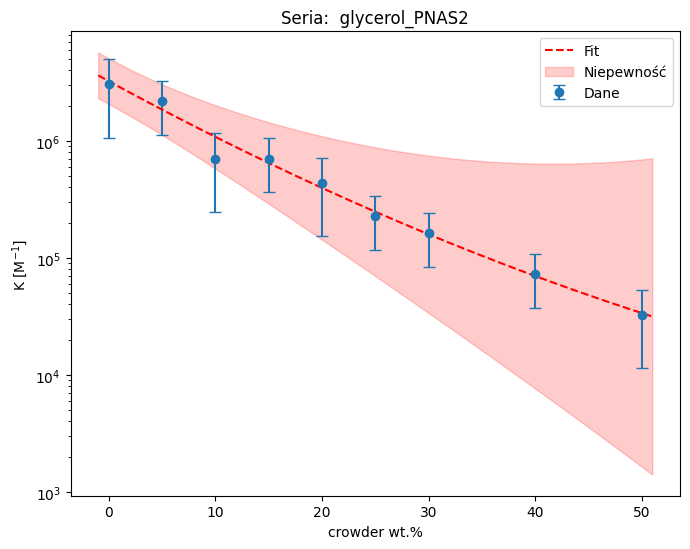

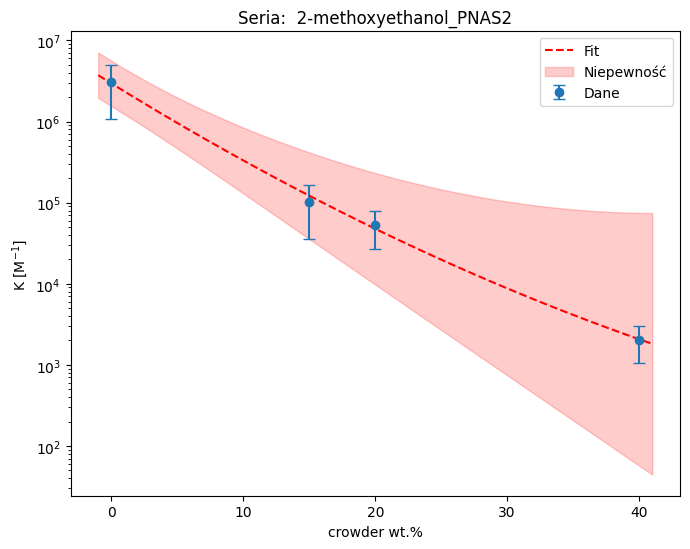

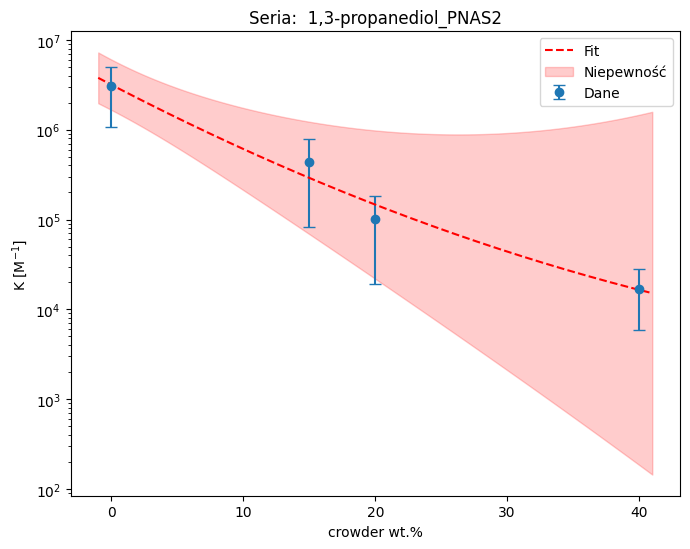

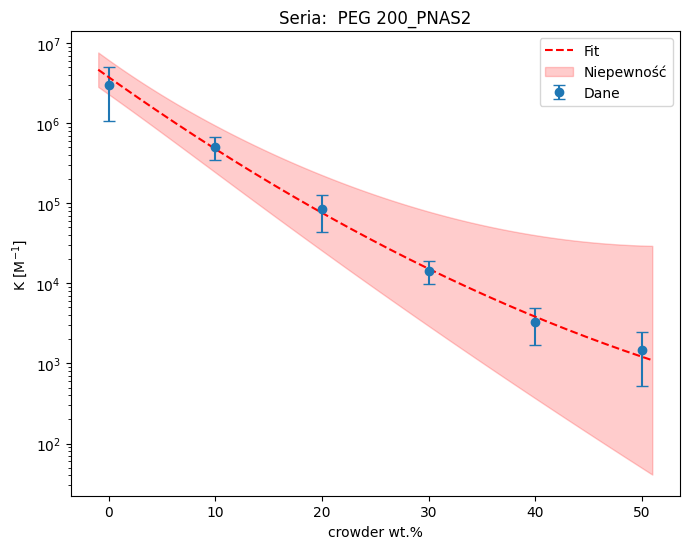

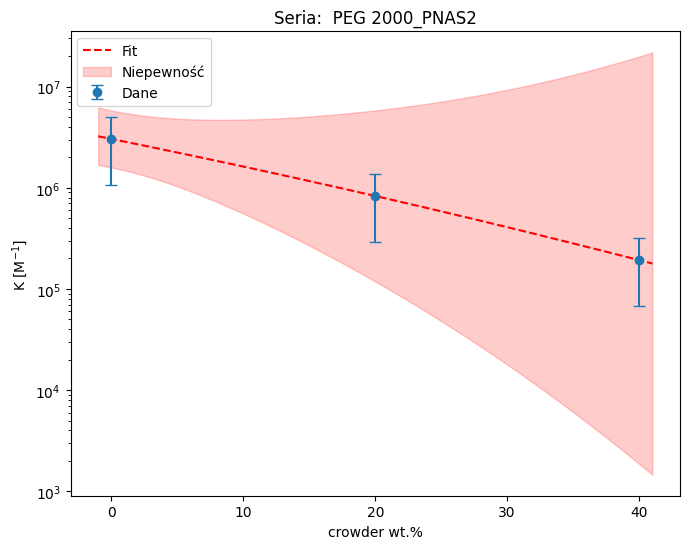

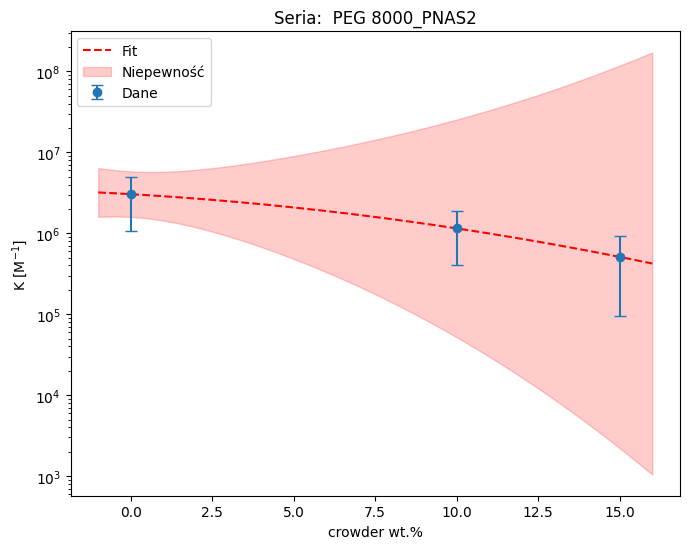

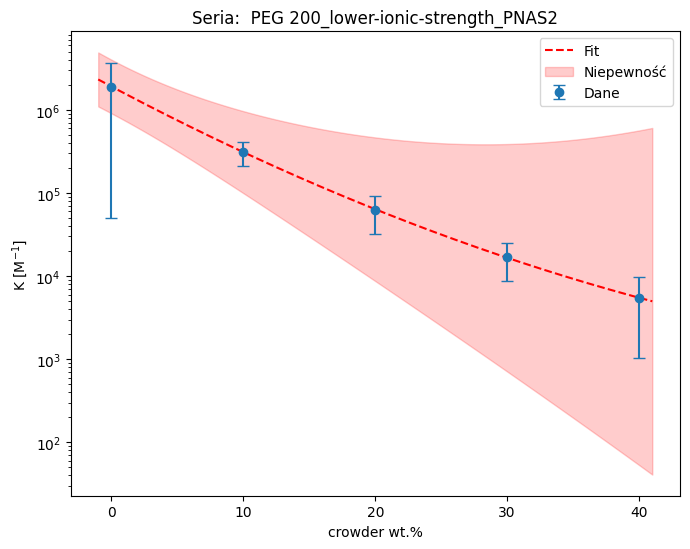

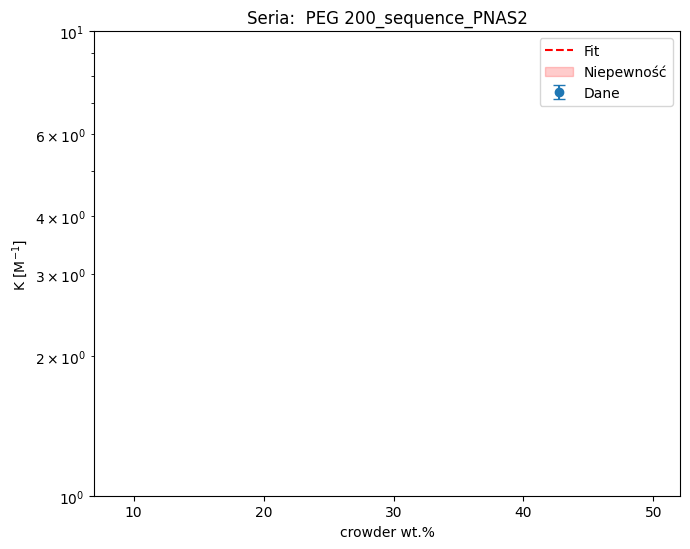

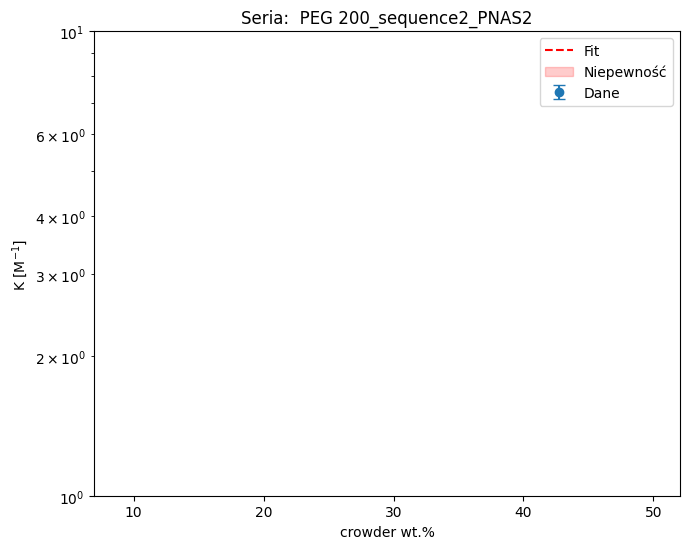

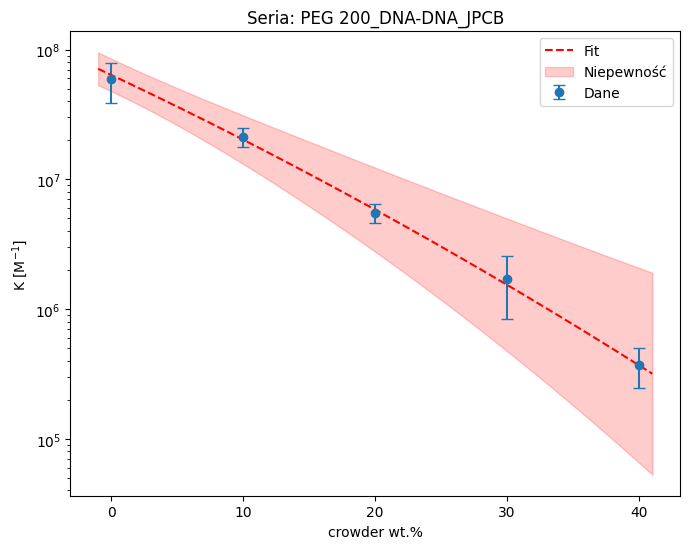

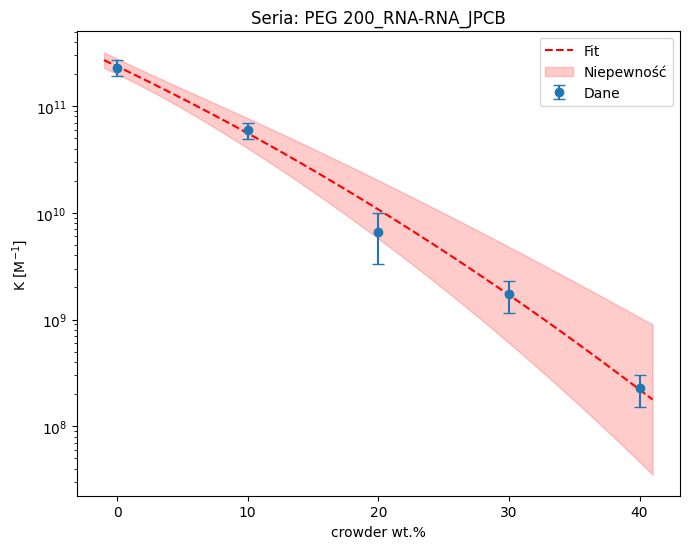

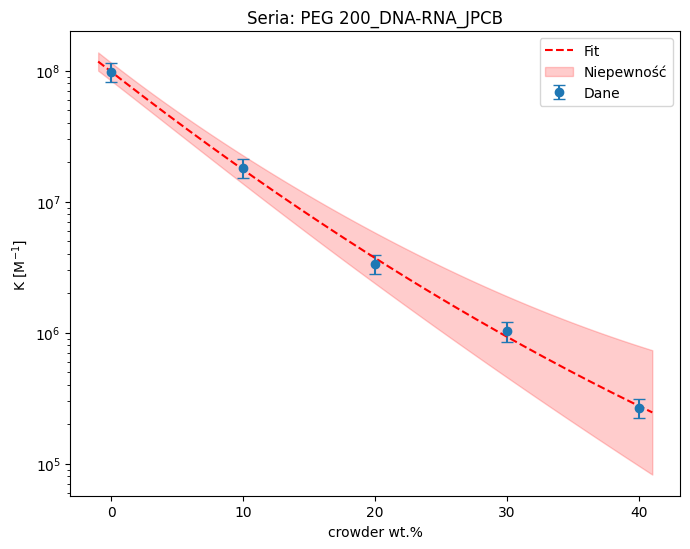

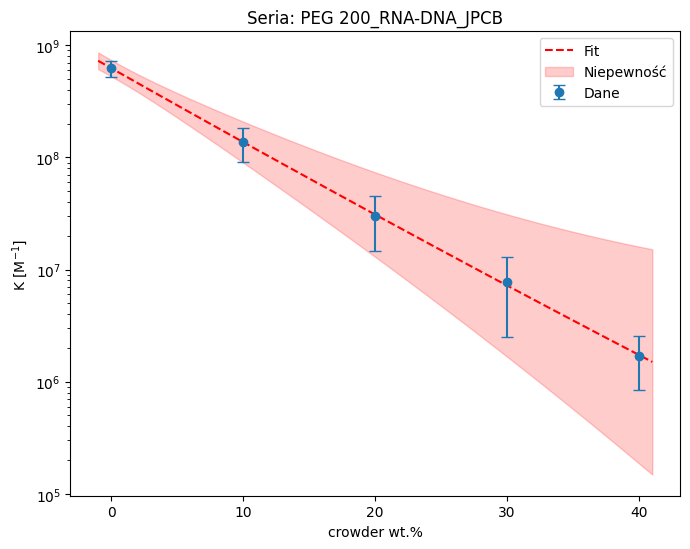

In [31]:
# Fit model
def quad_model(x, a0, a1, a2):
    return a0 + a1 * x + a2 * x**2

# Load and segregate data
df = pd.read_excel("C:/Users/tpiros/Desktop/ARTICLES/SUMMARY OTHERS.xlsx")
unique_series = df['name'].unique()

for series_name in unique_series:
    series_df = df[df['name'] == series_name]

    x = series_df['wt_%'].values
    y = series_df['K'].values
    yerr = series_df['K_err'].values
    log_y = np.log(y)

# Fit in wt.% for plotting
    try:
        popt, pcov = curve_fit(quad_model, x, log_y, sigma=yerr/y, absolute_sigma=True)
        a0, a1, a2 = popt
        a0_err, a1_err, a2_err = np.sqrt(np.diag(pcov))
    except Exception as e:
        print(f"Fit failed for {series_name}: {e}")
        continue

# Create plot
    plt.figure(figsize=(7, 5.6))

# Plot data points
    plt.errorbar(x, y, yerr=yerr, fmt='o', label='Dane', capsize=4)

# Fit curve and uncertainty band (in wt.%)
    x_fit = np.linspace(min(x) - 1, max(x) + 1, 200)
    lnK_fit = quad_model(x_fit, *popt)
    lnK_err = np.sqrt(
        a0_err**2 +
        (x_fit**2) * a1_err**2 +
        (x_fit**4) * a2_err**2
    )

    y_fit = np.exp(lnK_fit)
    y_upper = np.exp(lnK_fit + lnK_err)
    y_lower = np.exp(lnK_fit - lnK_err)

    # Rysuj dopasowanie i niepewność
    plt.plot(x_fit, y_fit, 'r--', label='Fit')
    plt.fill_between(x_fit, y_lower, y_upper, color='red', alpha=0.2, label='Niepewność')

    # Opis
    plt.title(f'Seria: {series_name}')
    plt.xlabel('crowder wt.%')
    plt.ylabel('K [M$^{-1}$]')
    plt.yscale('log')
    plt.legend()
    plt.tight_layout()

    # # Zapisz plik
    # filename = f"plots/fit_{series_name}.png"
    # plt.savefig(filename, dpi=300)
    # plt.close()
    # print(f"Zapisano wykres: {filename}")


In [47]:
fit_results = []

for series_name in unique_series:
    series_df = df[df['name'] == series_name]

    x = series_df['wt_%'].values
    y = series_df['K'].values
    yerr = series_df['K_err'].values
    log_y = np.log(y)

    try:
        popt, pcov = curve_fit(quad_model, x, log_y, sigma=yerr/y, absolute_sigma=True)
        a0, a1, a2 = popt
        a0_err, a1_err, a2_err = np.sqrt(np.diag(pcov))

        fit_results.append({
            'name': series_name,
            'a0': a0, 'a0_err': a0_err,
            'a1': a1, 'a1_err': a1_err,
            'a2': a2, 'a2_err': a2_err
        })
    except Exception as e:
        print(f"Fit failed for {series_name}: {e}")
        continue

# Tworzymy DataFrame
fit_df = pd.DataFrame(fit_results)
fit_df

Fit failed for nan: `ydata` must not be empty!


C:\Users\tpiros\AppData\Local\Temp\ipykernel_14396\3805622561.py:12: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(quad_model, x, log_y, sigma=yerr/y, absolute_sigma=True)


,name,a0,a0_err,a1,a1_err,a2,a2_err
0,Glycerol_JPCL,20.608869,0.109504,0.005219,0.015622,-0.002889,0.000348
1,Ficoll400_JPCL,20.571457,0.112053,0.033002,0.019533,-0.001744,0.000399
2,Dextran40000_JPCL,20.570296,0.111684,0.034499,0.021934,-0.002387,0.000493
3,Dextran70000_JPCL,20.581503,0.111781,-0.002807,0.020073,-0.001325,0.000454
4,EG_JACS,18.918031,0.667784,-0.165268,0.065498,0.000087,0.001637
5,glycerol_JACS,18.992732,0.468042,-0.168161,0.044141,0.001422,0.000876
6,PEG200_JACS,18.804520,0.513435,-0.232895,0.046882,0.001162,0.000920
7,PEG8000_JACS,18.948519,0.672807,-0.248200,0.158527,0.009849,0.007782
8,PEG200_lower-ionic-strength_JACS,17.153873,0.661009,-0.080334,0.061405,-0.001594,0.001128
9,Ethylene glycol_PNAS,17.287385,0.028961,0.068747,0.004244,-0.001427,0.000126
